# 🌾 Crop Species Detection

This notebook is a **public-facing inference demo** for the hierarchical crop species detection model.

Upload an image and the pipeline will:

1. **Stage 1** — decide whether the image shows **cropland** or **no cropland**.
2. **Stage 2** — if cropland is detected, identify the **crop species** (banana, maize, millets, rapeseed, soya, sorghum, sunflower, vineyard, or wheat type crop).

This notebook is **inference-only**. No training, fine-tuning, or dataset access is required.

**How to use this notebook:** Open it in Google Colab, select a GPU runtime (`Runtime → Change runtime type → T4 GPU`), then choose **Runtime → Run all**. No knowledge of PyTorch, DINOv2, Git, or the original training pipeline is required.

---


## 1. Environment & GPU

Detect whether a GPU is available. The notebook works on both GPU (recommended, e.g. a Colab T4) and CPU-only runtimes — it will simply run slower on CPU.


In [1]:
import torch

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )
else:
    print("No GPU detected — running on CPU. Inference will be slower but will still work.")


Device: cuda
GPU: Tesla T4


## 2. Clone the Repository

Clone the model repository. This repository contains:

- `model.py` — the exact `DINOv2Classifier` architecture used to train both checkpoints.
- `models/stage1_best.pt` and `models/stage2_best.pt` — the trained checkpoints (stored with Git LFS, ~333 MB each).

We use the existing `DINOv2Classifier` class directly — it is **not** redefined anywhere in this notebook.


In [2]:
!git clone https://github.com/diegocaparrosvaquer/crop-species-detection-demo.git


Cloning into 'crop-species-detection-demo'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 14 (delta 1), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), done.
Resolving deltas: 100% (1/1), done.
Filtering content: 100% (2/2), 664.72 MiB | 4.78 MiB/s, done.


In [3]:
import sys

REPO_DIR = "/content/crop-species-detection-demo"

sys.path.insert(0, REPO_DIR)

print(f"Added {REPO_DIR} to sys.path")


Added /content/crop-species-detection-demo to sys.path


## 3. Install / Import Dependencies

Colab already ships with compatible versions of `torch`, `torchvision`, `numpy`, `pandas`, `matplotlib`, and `Pillow`. The repository's `requirements.txt` pins its own (older) versions of these same packages, and force-installing those pins — even with `pip`'s dependency resolution turned off — replaces Colab's `numpy` with a version whose C-ABI doesn't match the `pandas`/`matplotlib` wheels Colab preinstalled, causing errors like:

```
ValueError: numpy.dtype size changed, may indicate binary incompatibility.
```

To avoid this, we only install the packages from `requirements.txt` that Colab does **not** already provide (currently `timm` and `scikit-learn`), and leave `torch`, `torchvision`, `numpy`, `pandas`, `Pillow`, and `matplotlib` at the versions Colab ships.


In [4]:
# Packages that Colab already provides in a compatible version — do NOT
# reinstall these from requirements.txt, or you risk a numpy/pandas ABI
# mismatch (numpy.dtype size changed... binary incompatibility).
PREINSTALLED_ON_COLAB = {
    "torch", "torchvision", "numpy", "pandas", "pillow", "matplotlib",
    "scikit-learn",
}

req_path = "/content/crop-species-detection-demo/requirements.txt"

with open(req_path) as f:
    requirement_lines = [line.strip() for line in f if line.strip()]

def package_name(requirement_line: str) -> str:
    for sep in ("==", ">=", "<=", "~=", ">", "<"):
        if sep in requirement_line:
            return requirement_line.split(sep)[0].strip().lower()
    return requirement_line.strip().lower()

to_install = [
    line for line in requirement_lines
    if package_name(line) not in PREINSTALLED_ON_COLAB
]
skipped = [
    line for line in requirement_lines
    if package_name(line) in PREINSTALLED_ON_COLAB
]

print("Skipping (already provided by Colab):", skipped)
print("Installing:", to_install)

if to_install:
    filtered_req_path = "/content/filtered_requirements.txt"
    with open(filtered_req_path, "w") as f:
        f.write("\n".join(to_install) + "\n")
    !pip install -q --no-deps -r {filtered_req_path}

import numpy
print("\nnumpy:", numpy.__version__, "(left untouched, provided by Colab)")


Skipping (already provided by Colab): ['torch==2.5.1', 'torchvision==0.20.1', 'numpy==1.26.4', 'pandas==2.2.3', 'scikit-learn==1.6.1', 'Pillow==11.1.0', 'matplotlib==3.10.0']
Installing: ['timm==1.0.19']
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 56.7 MB/s eta 0:00:00

numpy: 2.0.2 (left untouched, provided by Colab)


In [5]:
import os
import io
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from IPython.display import display, HTML, Markdown

# Import the EXISTING model architecture from the cloned repository.
# This is the only place DINOv2Classifier comes from — it is not
# redefined or modified anywhere in this notebook.
from model import DINOv2Classifier

print("Imported DINOv2Classifier from:", DINOv2Classifier.__module__)


Imported DINOv2Classifier from: model


## 4. Download Model Checkpoints (Git LFS)

The two checkpoints (`stage1_best.pt` and `stage2_best.pt`) are tracked with **Git LFS**. A plain `git clone` may only download small LFS *pointer* files instead of the actual ~333 MB weights, so we explicitly pull the LFS content and verify the file sizes before proceeding.


In [6]:
!git lfs install
!git -C /content/crop-species-detection-demo lfs pull


Git LFS initialized.


In [7]:
stage1_path = os.path.join(REPO_DIR, "models", "stage1_best.pt")
stage2_path = os.path.join(REPO_DIR, "models", "stage2_best.pt")

# A real checkpoint should be on the order of hundreds of MB. If the
# file is only a few KB, Git LFS did not actually download the binary
# content and we are looking at a pointer file instead.
LFS_POINTER_SIZE_THRESHOLD_MB = 1.0

def check_checkpoint_file(path, label):
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"{label} checkpoint not found.\n"
            f"Expected file at: {path}\n"
            f"Please make sure the repository was cloned successfully."
        )

    size_mb = os.path.getsize(path) / 1024 ** 2

    if size_mb < LFS_POINTER_SIZE_THRESHOLD_MB:
        raise RuntimeError(
            f"{label} checkpoint at '{path}' is only {size_mb:.3f} MB, "
            f"which is far too small to be a real model checkpoint.\n"
            f"This usually means Git LFS did not download the actual file "
            f"and you are looking at an LFS pointer file instead.\n\n"
            f"Fix: run the following in a cell and re-run this cell:\n"
            f"    !git lfs install\n"
            f"    !git -C {REPO_DIR} lfs pull"
        )

    print(f"{label}: {size_mb:.2f} MB")
    return size_mb

check_checkpoint_file(stage1_path, "Stage 1")
check_checkpoint_file(stage2_path, "Stage 2")


Stage 1: 332.36 MB
Stage 2: 332.36 MB


332.3630256652832

## 5. Load DINOv2 Models

Load both checkpoints, read off the class lists that were saved alongside the model weights during training, and instantiate `DINOv2Classifier` (imported from `model.py`) for each stage.


In [8]:
stage1_checkpoint = torch.load(
    stage1_path,
    map_location="cpu"
)

stage2_checkpoint = torch.load(
    stage2_path,
    map_location="cpu"
)

stage1_classes = stage1_checkpoint["classes"]
stage1_class_to_idx = stage1_checkpoint["class_to_idx"]

stage2_classes = stage2_checkpoint["classes"]
stage2_class_to_idx = stage2_checkpoint["class_to_idx"]

stage1_idx_to_class = {
    int(index): class_name
    for class_name, index
    in stage1_class_to_idx.items()
}

stage2_idx_to_class = {
    int(index): class_name
    for class_name, index
    in stage2_class_to_idx.items()
}

print("Stage 1 classes:", stage1_classes)
print("Stage 2 classes:", stage2_classes)


Stage 1 classes: ['no cropland', 'cropland']
Stage 2 classes: ['banana', 'maize', 'millets', 'rapeseed', 'soya', 'sorghum', 'sunflower', 'vineyard', 'wheat type crop']


## 6. Verify Checkpoints

Before doing anything else, sanity-check that the checkpoints contain the classes we expect. This catches accidental use of the wrong checkpoint file early, with a clear error message instead of a confusing failure later.


In [9]:
EXPECTED_STAGE1_CLASSES = {"no cropland", "cropland"}

EXPECTED_STAGE2_CLASSES = {
    "banana",
    "maize",
    "millets",
    "rapeseed",
    "soya",
    "sorghum",
    "sunflower",
    "vineyard",
    "wheat type crop",
}

def verify_classes(actual_classes, expected_classes, label):
    actual_set = set(actual_classes)
    if actual_set != expected_classes:
        missing = expected_classes - actual_set
        unexpected = actual_set - expected_classes
        raise ValueError(
            f"{label} checkpoint classes do not match the expected classes.\n"
            f"Missing: {sorted(missing) if missing else 'none'}\n"
            f"Unexpected: {sorted(unexpected) if unexpected else 'none'}"
        )
    print(f"✓ {label} classes verified: {actual_classes}")

verify_classes(stage1_classes, EXPECTED_STAGE1_CLASSES, "Stage 1")
verify_classes(stage2_classes, EXPECTED_STAGE2_CLASSES, "Stage 2")


✓ Stage 1 classes verified: ['no cropland', 'cropland']
✓ Stage 2 classes verified: ['banana', 'maize', 'millets', 'rapeseed', 'soya', 'sorghum', 'sunflower', 'vineyard', 'wheat type crop']


In [10]:
# Instantiate both models using the EXISTING DINOv2Classifier from model.py.
# We do not modify the architecture to make checkpoints "fit" — if loading
# fails, we report the error clearly instead.

stage1_model = DINOv2Classifier(num_classes=len(stage1_classes))
stage2_model = DINOv2Classifier(num_classes=len(stage2_classes))

def load_checkpoint_strict(model, checkpoint, label):
    try:
        result = model.load_state_dict(checkpoint["model_state_dict"])
    except Exception as e:
        raise RuntimeError(
            f"Failed to load {label} checkpoint into DINOv2Classifier.\n"
            f"This means the checkpoint does not match the architecture in model.py.\n"
            f"The architecture was NOT modified to force a fit.\n\n"
            f"Underlying error:\n{e}"
        )

    if result.missing_keys or result.unexpected_keys:
        raise RuntimeError(
            f"{label} checkpoint loaded with mismatched keys.\n"
            f"Missing keys: {result.missing_keys}\n"
            f"Unexpected keys: {result.unexpected_keys}\n"
            f"The architecture was NOT modified to force a fit."
        )

    print(f"✓ {label} checkpoint loaded successfully")

load_checkpoint_strict(stage1_model, stage1_checkpoint, "Stage 1")
load_checkpoint_strict(stage2_model, stage2_checkpoint, "Stage 2")

stage1_model = stage1_model.to(device)
stage2_model = stage2_model.to(device)

# Load models exactly once, then reuse them for every image.
stage1_model.eval()
stage2_model.eval()

print("\nBoth models are loaded, on device, and in eval mode.")


Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:01<00:00, 231MB/s]
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


✓ Stage 1 checkpoint loaded successfully
✓ Stage 2 checkpoint loaded successfully

Both models are loaded, on device, and in eval mode.


## 7. Image Preprocessing

Apply the same preprocessing used during evaluation: resize to 224×224, convert to a tensor, and normalize with ImageNet statistics. Images are always converted to RGB first, so grayscale or RGBA uploads work correctly too.


In [11]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

def preprocess_image(image: Image.Image) -> torch.Tensor:
    image = image.convert("RGB")
    tensor = transform(image).unsqueeze(0)  # add batch dimension
    return tensor


## 8. Hierarchical Inference Function

`predict_image()` runs the full hierarchical pipeline on a single PIL image:

1. Run **Stage 1**. If it predicts `no cropland`, stop — the final prediction is `no cropland`.
2. Otherwise, run **Stage 2** and use its output as the final prediction.

Inference always runs under `torch.inference_mode()` on whichever device the models were loaded to, and the models are never reloaded per image.


In [12]:
def predict_image(image: Image.Image) -> dict:
    """Run the hierarchical (Stage 1 -> Stage 2) inference pipeline on a single image.

    Returns a dict with:
        stage1_prediction, stage1_confidence,
        stage2_prediction, stage2_confidence,
        final_prediction, final_confidence,
        stage2_used,
        stage1_probs (dict class -> probability),
        stage2_probs (dict class -> probability, or None)
    """
    image_tensor = preprocess_image(image).to(device)

    with torch.inference_mode():
        stage1_logits = stage1_model(image_tensor)
        stage1_probs_tensor = torch.softmax(stage1_logits, dim=1)[0]

    stage1_probs_tensor_cpu = stage1_probs_tensor.detach().cpu()
    stage1_pred_idx = int(torch.argmax(stage1_probs_tensor_cpu).item())
    stage1_prediction = stage1_idx_to_class[stage1_pred_idx]
    stage1_confidence = float(stage1_probs_tensor_cpu[stage1_pred_idx].item())

    stage1_probs = {
        stage1_idx_to_class[i]: float(p)
        for i, p in enumerate(stage1_probs_tensor_cpu.tolist())
    }

    result = {
        "stage1_prediction": stage1_prediction,
        "stage1_confidence": stage1_confidence,
        "stage2_prediction": None,
        "stage2_confidence": None,
        "final_prediction": None,
        "final_confidence": None,
        "stage2_used": False,
        "stage1_probs": stage1_probs,
        "stage2_probs": None,
    }

    if stage1_prediction != "cropland":
        # No cropland detected -> Stage 2 is not executed.
        result["final_prediction"] = "no cropland"
        result["final_confidence"] = stage1_confidence
        return result

    with torch.inference_mode():
        stage2_logits = stage2_model(image_tensor)
        stage2_probs_tensor = torch.softmax(stage2_logits, dim=1)[0]

    stage2_probs_tensor_cpu = stage2_probs_tensor.detach().cpu()
    stage2_pred_idx = int(torch.argmax(stage2_probs_tensor_cpu).item())
    stage2_prediction = stage2_idx_to_class[stage2_pred_idx]
    stage2_confidence = float(stage2_probs_tensor_cpu[stage2_pred_idx].item())

    stage2_probs = {
        stage2_idx_to_class[i]: float(p)
        for i, p in enumerate(stage2_probs_tensor_cpu.tolist())
    }

    result["stage2_prediction"] = stage2_prediction
    result["stage2_confidence"] = stage2_confidence
    result["stage2_used"] = True
    result["stage2_probs"] = stage2_probs
    result["final_prediction"] = stage2_prediction
    result["final_confidence"] = stage2_confidence

    return result

print("predict_image() is ready.")


predict_image() is ready.


## 9. Upload an Image

Upload a single image (`.jpg`, `.jpeg`, `.png`, or `.webp`) to run through the pipeline.


Please choose an image file to upload (.jpg, .jpeg, .png, .webp)


Saving alabamasunflowers-35.webp to alabamasunflowers-35.webp


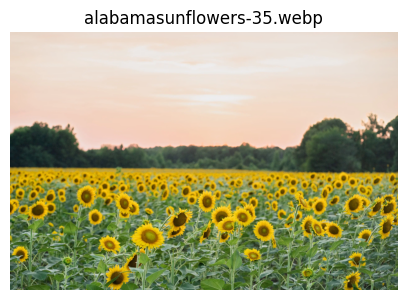

In [13]:
from google.colab import files

SUPPORTED_EXTENSIONS = (".jpg", ".jpeg", ".png", ".webp")

print("Please choose an image file to upload (.jpg, .jpeg, .png, .webp)")
uploaded = files.upload()

if not uploaded:
    raise RuntimeError("No file was uploaded. Please re-run this cell and select an image.")

uploaded_filename = next(iter(uploaded))

if not uploaded_filename.lower().endswith(SUPPORTED_EXTENSIONS):
    raise ValueError(
        f"Unsupported file type: '{uploaded_filename}'.\n"
        f"Please upload one of: {', '.join(SUPPORTED_EXTENSIONS)}"
    )

try:
    uploaded_image = Image.open(io.BytesIO(uploaded[uploaded_filename]))
    uploaded_image.load()
except Exception as e:
    raise ValueError(
        f"Could not open '{uploaded_filename}' as an image. "
        f"Please make sure it is a valid .jpg, .jpeg, .png, or .webp file.\n"
        f"Underlying error: {e}"
    )

plt.figure(figsize=(5, 5))
plt.imshow(uploaded_image.convert("RGB"))
plt.axis("off")
plt.title(uploaded_filename)
plt.show()


## 10. Prediction

Run the hierarchical pipeline on the uploaded image and display a clean summary.


In [14]:
result = predict_image(uploaded_image)
result


{'stage1_prediction': 'cropland',
 'stage1_confidence': 0.9998911619186401,
 'stage2_prediction': 'sunflower',
 'stage2_confidence': 0.9998161196708679,
 'final_prediction': 'sunflower',
 'final_confidence': 0.9998161196708679,
 'stage2_used': True,
 'stage1_probs': {'no cropland': 0.00010880286572501063,
  'cropland': 0.9998911619186401},
 'stage2_probs': {'banana': 2.855493903552997e-06,
  'maize': 2.633997064549476e-05,
  'millets': 2.691416057132301e-06,
  'rapeseed': 9.676266927272081e-06,
  'soya': 2.3153945221565664e-05,
  'sorghum': 0.00010444301005918533,
  'sunflower': 0.9998161196708679,
  'vineyard': 6.984430910961237e-06,
  'wheat type crop': 7.737270607321989e-06}}

In [15]:
def render_prediction_html(result: dict) -> str:
    stage2_html = ""
    if result["stage2_used"]:
        stage2_html = f"""
        <tr><td style="padding:4px 12px;"><b>Stage 2</b></td><td></td></tr>
        <tr><td style="padding:2px 24px;">Prediction</td><td>{result['stage2_prediction'].upper()}</td></tr>
        <tr><td style="padding:2px 24px;">Confidence</td><td>{result['stage2_confidence']*100:.2f}%</td></tr>
        """
    else:
        stage2_html = """
        <tr><td style="padding:4px 12px;" colspan="2"><i>Stage 2 was not executed (no cropland detected).</i></td></tr>
        """

    final_label = result["final_prediction"].replace("_", " ").title()
    emoji = "🚫" if result["final_prediction"] == "no cropland" else "🌾"

    html = f"""
    <div style="border:2px solid #2e7d32; border-radius:10px; padding:16px 20px; font-family:sans-serif; max-width:480px;">
      <h2 style="margin-top:0; color:#2e7d32;">🌾 Crop Species Detection</h2>
      <table style="width:100%; border-collapse:collapse;">
        <tr><td style="padding:4px 12px;"><b>Stage 1</b></td><td></td></tr>
        <tr><td style="padding:2px 24px;">Prediction</td><td>{result['stage1_prediction'].upper()}</td></tr>
        <tr><td style="padding:2px 24px;">Confidence</td><td>{result['stage1_confidence']*100:.2f}%</td></tr>
        {stage2_html}
      </table>
      <hr style="margin:12px 0;">
      <div style="font-size:1.1em;">
        <b>FINAL PREDICTION</b><br>
        {emoji} <b>{final_label}</b><br>
        Confidence: {result['final_confidence']*100:.2f}%
      </div>
    </div>
    """
    return html

display(HTML(render_prediction_html(result)))


Stage 1,
Prediction,CROPLAND
Confidence,99.99%
Stage 2,
Prediction,SUNFLOWER
Confidence,99.98%


## 11. Probability Visualization

Show a horizontal bar chart of the Stage 1 probabilities, and — if Stage 2 was executed — the full set of Stage 2 crop-species probabilities. Bars are sorted from highest to lowest probability.


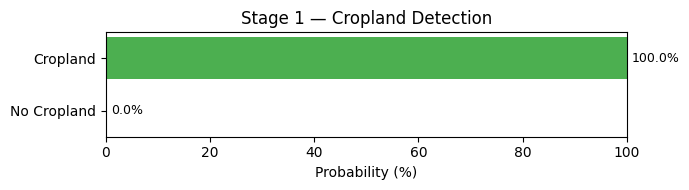

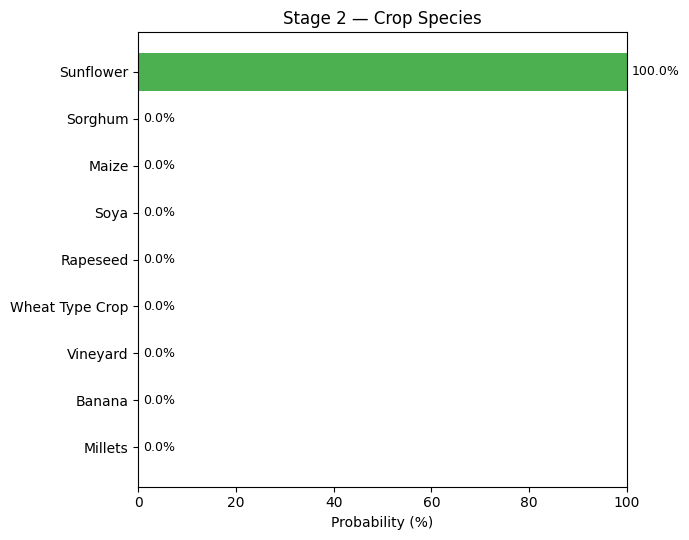

In [16]:
def plot_probabilities(probs: dict, title: str):
    items = sorted(probs.items(), key=lambda x: x[1], reverse=True)
    labels = [k.replace("_", " ").title() for k, _ in items]
    values = [v * 100 for _, v in items]

    fig_height = max(2, 0.5 * len(labels) + 1)
    fig, ax = plt.subplots(figsize=(7, fig_height))

    bars = ax.barh(labels, values, color="#4caf50")
    ax.invert_yaxis()  # highest probability on top
    ax.set_xlabel("Probability (%)")
    ax.set_xlim(0, 100)
    ax.set_title(title)

    for bar, value in zip(bars, values):
        ax.text(
            bar.get_width() + 1,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.1f}%",
            va="center",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()

plot_probabilities(result["stage1_probs"], "Stage 1 — Cropland Detection")

if result["stage2_used"]:
    plot_probabilities(result["stage2_probs"], "Stage 2 — Crop Species")
else:
    print("Stage 2 was not executed, so there are no crop-species probabilities to show.")


## 12. Optional: Batch Prediction

Upload multiple images at once to run the full pipeline on each of them, and collect the results into a single table.


In [17]:
print("Please choose one or more image files to upload (.jpg, .jpeg, .png, .webp)")
batch_uploaded = files.upload()

batch_rows = []

for filename, file_bytes in batch_uploaded.items():
    if not filename.lower().endswith(SUPPORTED_EXTENSIONS):
        print(f"Skipping '{filename}': unsupported file type.")
        continue

    try:
        img = Image.open(io.BytesIO(file_bytes))
        img.load()
    except Exception as e:
        print(f"Skipping '{filename}': could not be opened as an image ({e}).")
        continue

    res = predict_image(img)
    batch_rows.append({
        "image": filename,
        "stage1_prediction": res["stage1_prediction"],
        "stage1_confidence": res["stage1_confidence"],
        "stage2_prediction": res["stage2_prediction"],
        "stage2_confidence": res["stage2_confidence"],
        "final_prediction": res["final_prediction"],
        "final_confidence": res["final_confidence"],
    })

batch_df = pd.DataFrame(batch_rows, columns=[
    "image",
    "stage1_prediction", "stage1_confidence",
    "stage2_prediction", "stage2_confidence",
    "final_prediction", "final_confidence",
])

batch_df


Please choose one or more image files to upload (.jpg, .jpeg, .png, .webp)


Saving images (6).jpg to images (6).jpg
Saving istockphoto-1421187500-612x612.jpg to istockphoto-1421187500-612x612.jpg
Saving Rapeseed-20-yellow-fields.jpg to Rapeseed-20-yellow-fields.jpg
Saving istockphoto-1330394428-612x612.jpg to istockphoto-1330394428-612x612.jpg
Saving images (5).jpg to images (5).jpg
Saving images (4).jpg to images (4).jpg
Saving images (3).jpg to images (3).jpg
Saving images (2).jpg to images (2).jpg
Saving images (1).jpg to images (1).jpg
Saving alabamasunflowers-35.webp to alabamasunflowers-35 (1).webp


,image,stage1_prediction,stage1_confidence,stage2_prediction,stage2_confidence,final_prediction,final_confidence
0,images (6).jpg,cropland,0.999665,vineyard,0.997878,vineyard,0.997878
1,istockphoto-1421187500-612x612.jpg,cropland,0.999746,maize,0.684445,maize,0.684445
2,Rapeseed-20-yellow-fields.jpg,cropland,0.999832,rapeseed,0.997889,rapeseed,0.997889
3,istockphoto-1330394428-612x612.jpg,cropland,0.999361,banana,0.999371,banana,0.999371
4,images (5).jpg,cropland,0.999030,soya,0.999689,soya,0.999689
5,images (4).jpg,cropland,0.999081,millets,0.998502,millets,0.998502
6,images (3).jpg,cropland,0.999790,sorghum,0.997711,sorghum,0.997711
7,images (2).jpg,cropland,0.999287,wheat type crop,0.993565,wheat type crop,0.993565
8,images (1).jpg,no cropland,0.954904,None,NaN,no cropland,0.954904
9,alabamasunflowers-35 (1).webp,cropland,0.999891,sunflower,0.999816,sunflower,0.999816


## 13. Model Performance

These metrics were obtained on the **held-out test set** used during evaluation. **Performance on user-uploaded images may differ** depending on image quality, geography, lighting, crop growth stage, and image distribution — these numbers are reported for transparency, not as guarantees.

### Complete hierarchical pipeline
| Metric | Value |
|---|---|
| Accuracy | 93.72% |
| Balanced Accuracy | 93.34% |
| Macro F1 | 93.18% |
| Weighted F1 | 93.70% |

### Stage 1 (cropland vs. no cropland)
| Metric | Value |
|---|---|
| Accuracy | 95.19% |
| Balanced Accuracy | 95.49% |
| Macro F1 | 94.75% |

### Stage 2 (crop species, evaluated on true cropland)
| Metric | Value |
|---|---|
| Accuracy | 97.10% |
| Balanced Accuracy | 95.88% |
| Macro F1 | 95.04% |
| Weighted F1 | 97.12% |


## 14. Why a Hierarchical Model?

```
                    Image
                      │
                      ▼
                ┌───────────┐
                │  Stage 1  │
                └─────┬─────┘
                      │
             ┌────────┴────────┐
             │                 │
             ▼                 ▼
        No cropland         Cropland
             │                 │
             ▼                 ▼
        Final result       ┌───────────┐
                           │  Stage 2  │
                           └─────┬─────┘
                                 │
                                 ▼
                           Crop species
```

Instead of forcing a single classifier to distinguish non-cropland imagery from multiple crop species simultaneously, this hierarchical architecture first determines whether an image represents cropland at all, and only then performs fine-grained crop-species classification — and only when that is actually appropriate. This keeps each stage focused on a simpler decision, which tends to improve accuracy and interpretability compared to a single flat classifier.


## Conclusion

This notebook demonstrates end-to-end inference with the hierarchical crop species detection model:

- **Stage 1** distinguishes cropland from non-cropland imagery.
- **Stage 2** identifies the crop species, but only runs when Stage 1 detects cropland.

Everything here runs entirely inside the Colab runtime after cloning the repository — no external servers, S3 buckets, or Docker containers are required. This notebook is inference-only; no training, fine-tuning, or dataset access is performed.

For details on the model architecture, see `model.py` in the [repository](https://github.com/diegocaparrosvaquer/crop-species-detection-demo).
